In [1]:
!pip install --quiet pydicom nibabel scikit-image tqdm shap streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 125.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 117.3 MB/s eta 0:00:00


In [2]:
# ============================================
# 0) SETUP & IMPORTS
# ============================================
!pip install --quiet pydicom nibabel scikit-image tqdm shap

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os, random, math
import numpy as np
import pandas as pd
import pydicom
from tqdm import tqdm
from scipy.ndimage import zoom as ndzoom
from collections import defaultdict
import concurrent.futures

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_fscore_support, confusion_matrix, classification_report
)

import tensorflow as tf
from tensorflow.keras import layers, models

import shap
import matplotlib.pyplot as plt

# reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# let TF not grab the whole GPU at once
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled.")
    except Exception as e:
        print("Could not set memory growth:", e)
print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# ============================================
# 1) PATHS
# ============================================
PROJECT_ROOT = Path("/content/drive/MyDrive/capstone/tumor_pred_ai")
RAW_DIR_CANDIDATE = PROJECT_ROOT / "DataSet" / "RawData-M"
CLINICAL_CSV = RAW_DIR_CANDIDATE / "C4KC-KiTS_Clinical-Data_Version_m.csv"
META_CSV     = RAW_DIR_CANDIDATE / "metadata_m.csv"
IMAGE_ROOT   = RAW_DIR_CANDIDATE / "C4KC-KiTS"

if not CLINICAL_CSV.exists():
    raise FileNotFoundError(f"Clinical CSV not found at {CLINICAL_CSV}")
clinical_df = pd.read_csv(CLINICAL_CSV)

if META_CSV.exists():
    meta_df = pd.read_csv(META_CSV)
else:
    meta_df = None
    print("[warn] metadata CSV not found, continuing with clinical only")

# detect id columns
id_candidates = [c for c in clinical_df.columns
                 if 'patient' in c.lower() or 'subject' in c.lower() or c.lower() == 'id']
clinical_id_col = id_candidates[0] if id_candidates else clinical_df.columns[0]
print("Clinical ID column:", clinical_id_col)

if meta_df is not None:
    meta_id_candidates = [c for c in meta_df.columns
                          if 'patient' in c.lower() or 'subject' in c.lower() or c.lower() == 'id']
    meta_id_col = meta_id_candidates[0] if meta_id_candidates else meta_df.columns[0]
    merged_df = pd.merge(clinical_df, meta_df,
                         left_on=clinical_id_col,
                         right_on=meta_id_col,
                         how='left')
    join_key = clinical_id_col
    print("Merged shape:", merged_df.shape)
else:
    merged_df = clinical_df.copy()
    join_key = clinical_id_col
    print("Clinical only shape:", merged_df.shape)

if not IMAGE_ROOT.exists():
    raise FileNotFoundError(f"IMAGE_ROOT does not exist: {IMAGE_ROOT}")


Clinical ID column: patient_id
Merged shape: (40, 77)


In [ ]:
# ============================================
# 2) GLOBAL PREPROCESS PARAMS
# ============================================
CLIP_HU = (-200, 300)
# smaller target to reduce memory, using (H,W,D) later
TARGET_SHAPE = (96, 96, 48)   # H, W, D in final tensor
PROCESS_LIMIT = None          # set e.g. 20 if you want quick test

MAX_WORKERS = min(8, os.cpu_count() or 8)
PATIENTS_PER_CHUNK = 200
ENABLE_RADIOMICS = False  # set True later when everything else works

# ============================================
# 3) DICOM + RADIOMICS HELPERS
# ============================================
def clip_and_normalize_hu(vol, clip=CLIP_HU):
    v = np.clip(vol, clip[0], clip[1]).astype(np.float32)
    v = (v - clip[0]) / (clip[1] - clip[0] + 1e-9)
    return v

def resize_volume_to_target_phys(vol, spacing, target_shape=TARGET_SHAPE):
    """
    vol: (Z,H,W) in HU
    spacing: (dz, dy, dx)
    target_shape: (H, W, D) for final model input
    """
    if vol is None:
        th, tw, td = target_shape
        return np.zeros((th, tw, td), dtype=np.float32)

    z, h, w = vol.shape
    th, tw, td = target_shape

    # first resize to (td, th, tw) on (Z,H,W)
    zoom_factors = (
        td / (z if z > 0 else 1),
        th / (h if h > 0 else 1),
        tw / (w if w > 0 else 1),
    )
    try:
        vr = ndzoom(vol, zoom_factors, order=1)  # (td, th, tw)
    except Exception as e:
        print("[warn] zoom failed:", e)
        return np.zeros((th, tw, td), dtype=np.float32)

    # transpose to (H,W,D)
    vr = np.transpose(vr, (1, 2, 0))
    return vr

# robust DICOM loader (2D slices only)
def load_dicom_series_to_volume(folder: Path):
    folder = Path(folder)
    files = sorted(folder.glob("*.dcm"))
    if not files:
        files = sorted(folder.rglob("*.dcm"))
    if not files:
        return None

    candidate_slices = []
    for f in files:
        try:
            ds = pydicom.dcmread(str(f), stop_before_pixels=False, force=True)
            if hasattr(ds, 'pixel_array') and ds.pixel_array is not None and ds.pixel_array.size > 0:
                if ds.pixel_array.ndim == 2:
                    candidate_slices.append(ds)
        except Exception:
            continue
    if not candidate_slices:
        return None

    # group by shape
    slices_by_shape = defaultdict(list)
    for s in candidate_slices:
        slices_by_shape[s.pixel_array.shape].append(s)

    if not slices_by_shape:
        return None

    most_common_shape = max(slices_by_shape, key=lambda shape: len(slices_by_shape[shape]))
    good_slices = slices_by_shape[most_common_shape]

    if len(good_slices) < 3:
        return None

    def zpos(s):
        try:
            return float(s.ImagePositionPatient[2])
        except:
            return None

    good_slices.sort(key=lambda s: (zpos(s) is None, zpos(s), getattr(s, 'InstanceNumber', 1)))

    vol = np.stack([s.pixel_array for s in good_slices]).astype(np.int16)
    for i, s in enumerate(good_slices):
        slope = float(getattr(s, 'RescaleSlope', 1.0))
        intercept = float(getattr(s, 'RescaleIntercept', 0.0))
        vol[i] = (vol[i].astype(np.float32) * slope + intercept).astype(np.int16)

    try:
        ps = good_slices[0].PixelSpacing
        dz = float(getattr(good_slices[0], 'SliceThickness', 1.0))
        spacing = (dz, float(ps[0]), float(ps[1]))
    except Exception:
        spacing = (1.0, 1.0, 1.0)

    return vol, spacing

# radiomics helpers (light)
try:
    from skimage.filters import threshold_otsu
    from skimage.feature import graycomatrix, graycoprops
    from skimage.measure import marching_cubes, label as sk_label
    _SKIMAGE_AVAILABLE = True
except ImportError:
    _SKIMAGE_AVAILABLE = False
    print("[warn] skimage not available, radiomics will be zeros")

def _hu_to_uint8(vol, hu_range=(-200, 300)):
    vol = np.nan_to_num(vol, nan=0.0, posinf=hu_range[1], neginf=hu_range[0])
    lo, hi = hu_range
    if hi <= lo:
        hi = lo + 1
    v = np.clip(vol, lo, hi)
    v = (255.0 * (v - lo) / (hi - lo)).astype(np.uint8)
    return v

def _quick_mask(vol_hwd, hu_range=(-200, 300)):
    if not _SKIMAGE_AVAILABLE:
        return np.zeros_like(vol_hwd, dtype=bool)
    v8 = _hu_to_uint8(vol_hwd, hu_range)
    try:
        t = threshold_otsu(v8)
    except Exception:
        t = 1
    m = (v8 >= t).astype(np.uint8)
    lab = sk_label(m)
    if lab.max() == 0:
        return m.astype(bool)
    counts = np.bincount(lab.ravel())
    if counts.size > 1:
        largest = counts[1:].argmax() + 1
        return (lab == largest)
    else:
        return m.astype(bool)

def _glcm_feats(slice_u8, distances=(1,2,3), angles=(0, np.pi/4, np.pi/2, 3*np.pi/4)):
    if not _SKIMAGE_AVAILABLE:
        return {
            'glcm_contrast': np.nan, 'glcm_dissim': np.nan, 'glcm_homo': np.nan,
            'glcm_energy': np.nan, 'glcm_corr': np.nan, 'glcm_ASM': np.nan
        }
    if slice_u8.max() == slice_u8.min() or slice_u8.size < 2:
        return {
            'glcm_contrast': 0.0, 'glcm_dissim': 0.0, 'glcm_homo': 1.0,
            'glcm_energy': 1.0, 'glcm_corr': 1.0, 'glcm_ASM': 1.0
        }
    try:
        g = graycomatrix(slice_u8, distances=distances, angles=angles,
                         levels=256, symmetric=True, normed=True)
        feats = {
            'glcm_contrast':   float(graycoprops(g, 'contrast').mean()),
            'glcm_dissim':     float(graycoprops(g, 'dissimilarity').mean()),
            'glcm_homo':       float(graycoprops(g, 'homogeneity').mean()),
            'glcm_energy':     float(graycoprops(g, 'energy').mean()),
            'glcm_corr':       float(graycoprops(g, 'correlation').mean()),
            'glcm_ASM':        float(graycoprops(g, 'ASM').mean()),
        }
        return feats
    except Exception:
        return {
            'glcm_contrast': np.nan, 'glcm_dissim': np.nan, 'glcm_homo': np.nan,
            'glcm_energy': np.nan, 'glcm_corr': np.nan, 'glcm_ASM': np.nan
        }

def compute_light_radiomics(vol, spacing=(1.0, 1.0, 1.0), mask=None):
    """
    vol: (Z,H,W) float HU
    spacing: (dz, dy, dx)
    returns dict of intensity + shape + texture
    """
    if not _SKIMAGE_AVAILABLE:
        return {
            'int_mean': np.nan,'int_std': np.nan,'int_min': np.nan,'int_max': np.nan,'int_skew': np.nan,'int_kurt': np.nan,
            'shape_volume_mm3': np.nan, 'shape_surface_mm2': np.nan, 'shape_sphericity': np.nan,
            'glcm_contrast': np.nan,'glcm_dissim': np.nan,'glcm_homo': np.nan,'glcm_energy': np.nan,'glcm_corr': np.nan,'glcm_ASM': np.nan
        }

    vol = np.asarray(vol, dtype=np.float32)             # (Z,H,W)
    vol_hwd = np.transpose(vol, (1, 2, 0))              # (H,W,D)
    spacing_hwd = (spacing[1], spacing[2], spacing[0])  # (dy, dx, dz)

    if mask is None:
        mask = _quick_mask(vol_hwd)
    else:
        mask = mask.astype(bool)

    vox = vol_hwd[mask]
    if vox.size == 0:
        stats = {'int_mean':0.0,'int_std':0.0,'int_min':0.0,'int_max':0.0,'int_skew':0.0,'int_kurt':0.0}
    else:
        mu = float(np.mean(vox))
        sd = float(np.std(vox))
        if sd < 1e-6:
            z = np.zeros_like(vox)
        else:
            z = (vox - mu) / sd
        skew_val = np.mean(z**3)
        kurt_val = np.mean(z**4) - 3
        stats = {
            'int_mean': mu,
            'int_std' : sd,
            'int_min' : float(np.min(vox)),
            'int_max' : float(np.max(vox)),
            'int_skew': float(skew_val if np.isfinite(skew_val) else 0.0),
            'int_kurt': float(kurt_val if np.isfinite(kurt_val) else 0.0),
        }

    # shape via marching cubes
    try:
        verts, faces, _, _ = marching_cubes(mask.astype(float), level=0.5, spacing=spacing_hwd)
        tri = verts[faces]
        a = np.linalg.norm(tri[:,1]-tri[:,0], axis=1)
        b = np.linalg.norm(tri[:,2]-tri[:,1], axis=1)
        c = np.linalg.norm(tri[:,0]-tri[:,2], axis=1)
        s = 0.5*(a+b+c)
        area = float(np.sum(np.sqrt(np.clip(s*(s-a)*(s-b)*(s-c), 0, None))))
    except Exception:
        area = 0.0

    vol_mm3 = float(mask.sum() * float(np.prod(spacing_hwd)))

    if area > 1e-6 and vol_mm3 > 0:
        sphericity = (np.pi**(1/3)) * ((6*vol_mm3)**(2/3)) / (area + 1e-6)
        sphericity = float(sphericity if np.isfinite(sphericity) else 0.0)
    else:
        sphericity = 0.0

    shape = {'shape_volume_mm3': vol_mm3, 'shape_surface_mm2': area, 'shape_sphericity': sphericity}

    v8 = _hu_to_uint8(vol_hwd)
    D = vol_hwd.shape[2]
    mids = sorted(list({max(0, min(D-1, D//4)),
                        max(0, min(D-1, D//2)),
                        max(0, min(D-1, 3*D//4))}))
    glcms = []
    for k in mids:
        sl = v8[:, :, k]
        msl = mask[:, :, k]
        if np.count_nonzero(msl) >= 25:
            glcms.append(_glcm_feats(sl))
    if glcms:
        tex = {}
        feature_keys = glcms[0].keys()
        for k in feature_keys:
            vals = [d[k] for d in glcms if not np.isnan(d.get(k, np.nan))]
            tex[k] = float(np.mean(vals)) if vals else np.nan
        all_keys = {k for d in glcms for k in d.keys()}
        for k in all_keys:
            if k not in tex:
                tex[k] = np.nan
    else:
        tex = {k: np.nan for k in ['glcm_contrast','glcm_dissim','glcm_homo','glcm_energy','glcm_corr','glcm_ASM']}

    feats = {**stats, **shape, **tex}
    feats_clean = {k: (v if np.isfinite(v) else 0.0) for k, v in feats.items()}
    return feats_clean

def choose_best_ct_series_folder(image_root: Path, patient_id: str):
    """
    Faster version.
    Only searches inside IMAGE_ROOT / patient_id, not the whole tree.
    Returns the subfolder with the largest number of DICOM slices.
    """
    image_root = Path(image_root)
    base = image_root / str(patient_id)

    if not base.exists():
        print(f"[warn] no folder found for patient {patient_id} under {base}")
        return None

    candidates = []

    # include the patient folder itself if it has dcm files
    dcm_here = list(base.glob("*.dcm"))
    if len(dcm_here) >= 3:
        candidates.append((len(dcm_here), base))

    # now only search inside this patient folder, not entire IMAGE_ROOT
    for p in base.rglob("*"):
        if not p.is_dir():
            continue
        dcm_files = list(p.glob("*.dcm"))
        if len(dcm_files) >= 3:   # need at least 3 slices to be useful
            candidates.append((len(dcm_files), p))

    if not candidates:
        print(f"[warn] no dcm series with >=3 slices for patient {patient_id}")
        return None

    # pick the folder with max number of slices
    candidates.sort(key=lambda t: t[0], reverse=True)
    best_count, best_folder = candidates[0]
    # optional: log once per patient
    # print(f"[info] patient {patient_id} -> {best_folder} with {best_count} slices")
    return best_folder


In [ ]:


# ============================================
# 4) FEATURE / COLUMN SELECTION
# ============================================
preferred = ['malignant','malignant_flag','is_malignant','tumor_present','cancer_present','vital_status']
TARGET_LABEL = next((c for c in merged_df.columns if c in preferred), merged_df.columns[-1])
print("TARGET_LABEL:", TARGET_LABEL)

exclude_cols = {join_key, TARGET_LABEL}
for excl in ['File Location','Download Timestamp']:
    exclude_cols.update([c for c in merged_df.columns if excl in c])

all_features = [c for c in merged_df.columns if c not in exclude_cols]
numeric_cols = merged_df[all_features].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in all_features if c not in numeric_cols][:8]  # limit categories
print("Numeric cols:", numeric_cols[:5], "...")
print("Cat cols:", cat_cols)

TARGET_LABEL: malignant
Numeric cols: ['age_at_nephrectomy', 'body_mass_index', 'pack_years', 'hospitalization', 'radiographic_size'] ...
Cat cols: ['gender', 'comorbidities__myocardial_infarction', 'comorbidities__congestive_heart_failure', 'comorbidities__peripheral_vascular_disease', 'comorbidities__cerebrovascular_disease', 'comorbidities__dementia', 'comorbidities__copd', 'comorbidities__connective_tissue_disease']


In [ ]:


# ============================================
# 5) PARALLEL PATIENT PROCESSING
# ============================================
unique_patient_ids = merged_df[join_key].astype(str).unique().tolist()
if PROCESS_LIMIT is not None:
    unique_patient_ids = unique_patient_ids[:PROCESS_LIMIT]

def process_one_patient(pid):
    folder = choose_best_ct_series_folder(IMAGE_ROOT, pid)
    if folder is None:
        return None
    load = load_dicom_series_to_volume(folder)
    if load is None:
        return None
    vol, spacing = load

    # image preprocess
    proc = clip_and_normalize_hu(vol, CLIP_HU)
    proc = resize_volume_to_target_phys(proc, spacing, TARGET_SHAPE)  # (H,W,D)

    # safety: enforce exact TARGET_SHAPE by crop/pad if needed
    if proc.shape != TARGET_SHAPE:
        H, W, D = TARGET_SHAPE
        h, w, d = proc.shape
        proc_fixed = np.zeros(TARGET_SHAPE, dtype=proc.dtype)
        proc_fixed[:min(H,h), :min(W,w), :min(D,d)] = proc[:min(H,h), :min(W,w), :min(D,d)]
        proc = proc_fixed

    # radiomics (optional)
    rad = compute_light_radiomics(vol, spacing=spacing) if ENABLE_RADIOMICS else {}

    # clinical
    rows = merged_df.loc[merged_df[join_key].astype(str) == pid]
    if rows.empty:
        return None
    row = rows.iloc[0]
    num_vec = row[numeric_cols].astype(float).fillna(0).values if numeric_cols else np.array([0.0], dtype=float)
    cat_vals = [str(row[c]) if pd.notna(row[c]) else 'NaN' for c in cat_cols] if cat_cols else []
    label_val = row.get(TARGET_LABEL, None)

    return {
        "pid": pid,
        "img": proc.astype(np.float32),
        "clin_num": num_vec,
        "clin_cat": cat_vals,
        "label": label_val,
        "rad": rad
    }

image_list, clin_list, label_list, radiomics_list, processed_patient_ids = [], [], [], [], []
rad_cols = []

n_patients = len(unique_patient_ids)
print("Total patients:", n_patients)

for start in range(0, n_patients, PATIENTS_PER_CHUNK):
    subset = unique_patient_ids[start:start + PATIENTS_PER_CHUNK]
    chunk_results = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
        futs = {ex.submit(process_one_patient, pid): pid for pid in subset}
        for fut in tqdm(concurrent.futures.as_completed(futs),
                        total=len(subset),
                        desc=f"Patients {start}-{start+len(subset)-1}"):
            try:
                # hard cap: 120 seconds max per patient
                r = fut.result(timeout=120)
            except concurrent.futures.TimeoutError:
                pid = futs[fut]
                print(f"[warn] skipping patient {pid} due to timeout")
                continue
            if r is not None:
                chunk_results.append(r)

    if ENABLE_RADIOMICS and not rad_cols:
        for r in chunk_results:
            if r["rad"]:
                rad_cols = list(r["rad"].keys())
                break

    for r in chunk_results:
        image_list.append(r["img"])
        clin_list.append((r["clin_num"], r["clin_cat"]))
        label_list.append(r["label"])
        processed_patient_ids.append(r["pid"])
        if ENABLE_RADIOMICS and rad_cols:
            radiomics_list.append({k: r["rad"].get(k, 0.0) for k in rad_cols})

print(f"Processed {len(processed_patient_ids)} patients")

if len(image_list) == 0:
    raise RuntimeError("No images loaded. Check IMAGE_ROOT structure.")


Total patients: 11


Patients 0-10: 100%|██████████| 11/11 [00:27<00:00,  2.46s/it]

Processed 11 patients


In [ ]:


# ============================================
# 6) BUILD TENSORS (X_img, X_clin, X_rad, y)
# ============================================
# X_img: (N,H,W,D,1)  Keras 3D input
X_img = np.stack(image_list).astype(np.float32)  # (N,H,W,D)
X_img = np.expand_dims(X_img, axis=-1)          # (N,H,W,D,1)

num_matrix = np.vstack([t[0] for t in clin_list])
cat_matrix = np.array([t[1] for t in clin_list], dtype=object)

try:
    enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    enc = OneHotEncoder(handle_unknown='ignore', sparse=False)

if cat_cols:
    cat_encoded = enc.fit_transform(cat_matrix)
else:
    cat_encoded = np.zeros((len(clin_list), 0))

X_clin = np.hstack([num_matrix, cat_encoded])
scaler = StandardScaler()
X_clin_scaled = scaler.fit_transform(X_clin.astype(float))

if ENABLE_RADIOMICS and radiomics_list and rad_cols:
    X_rad = np.vstack([[d[k] for k in rad_cols] for d in radiomics_list]).astype(float)
    rad_scaler = StandardScaler()
    X_rad_scaled = rad_scaler.fit_transform(X_rad)
else:
    X_rad_scaled = None

label_map = {
    'Yes':1,'Y':1,'True':1,'T':1,'Positive':1,'Malignant':1,'Dead':1,'Deceased':1,'1':1,1:1,
    'No':0,'N':0,'False':0,'F':0,'Negative':0,'Benign':0,'Alive':0,'0':0,0:0
}
def to01(v):
    if pd.isna(v):
        return 0
    s = str(v).strip()
    return label_map.get(v, label_map.get(s, 0))

y = np.array([to01(v) for v in label_list], dtype=int)

print("X_img:", X_img.shape)
print("X_clin_scaled:", X_clin_scaled.shape)
if X_rad_scaled is not None:
    print("X_rad_scaled:", X_rad_scaled.shape)
print("y:", y.shape, "  positive:", y.sum(), "  negative:", (y==0).sum())


X_img: (11, 96, 96, 48, 1)
X_clin_scaled: (11, 27)
y: (11,)   positive: 11   negative: 0


In [ ]:


# ============================================
# 7) TRAIN / VAL / TEST SPLIT
# ============================================
def smart_split_indices(y, test_frac=0.15, val_frac=0.15, random_state=42):
    y = np.asarray(y)
    N = len(y)
    rs = np.random.RandomState(random_state)
    if N <= 2:
        idx = np.arange(N); rs.shuffle(idx)
        if N == 1:
            return idx, np.array([], int), np.array([], int)
        return idx[:1], idx[1:], np.array([], int)

    class_to_idx = defaultdict(list)
    for i, yi in enumerate(y):
        class_to_idx[int(yi)].append(i)
    for k in class_to_idx:
        rs.shuffle(class_to_idx[k])
    train_idx, val_idx, test_idx = [], [], []
    for k, idxs in class_to_idx.items():
        n = len(idxs)
        n_test = int(round(n * test_frac))
        n_val  = int(round(n * val_frac))
        n_train = n - n_test - n_val
        if n_train < 1:
            n_train = n; n_val = 0; n_test = 0
        test_idx.extend(idxs[:n_test])
        val_idx.extend(idxs[n_test:n_test+n_val])
        train_idx.extend(idxs[n_test+n_val:])
    rs.shuffle(train_idx); rs.shuffle(val_idx); rs.shuffle(test_idx)
    return np.array(train_idx), np.array(val_idx), np.array(test_idx)

train_idx, val_idx, test_idx = smart_split_indices(
    y, test_frac=0.15, val_frac=0.15, random_state=RANDOM_SEED
)
print("Splits:", len(train_idx), len(val_idx), len(test_idx))

def take(a, idx):
    if a is None:
        return None
    a = np.asarray(a)
    return a[idx]

X_img_tr, X_img_va, X_img_te = take(X_img, train_idx), take(X_img, val_idx), take(X_img, test_idx)
X_clin_tr, X_clin_va, X_clin_te = take(X_clin_scaled, train_idx), take(X_clin_scaled, val_idx), take(X_clin_scaled, test_idx)
if X_rad_scaled is not None:
    X_rad_tr, X_rad_va, X_rad_te = take(X_rad_scaled, train_idx), take(X_rad_scaled, val_idx), take(X_rad_scaled, test_idx)
else:
    X_rad_tr = X_rad_va = X_rad_te = None
y_tr, y_va, y_te = take(y, train_idx), take(y, val_idx), take(y, test_idx)

print("X_img_tr:", X_img_tr.shape)
print("X_clin_tr:", X_clin_tr.shape)
print("y_tr:", y_tr.shape)


Splits: 7 2 2
X_img_tr: (7, 96, 96, 48, 1)
X_clin_tr: (7, 27)
y_tr: (7,)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

class LoRADense(layers.Layer):
    def __init__(
        self,
        units,
        rank=None,   # you call it with rank=8
        r=None,      # backward-compat if older code used r=
        alpha=16.0,
        dropout=0.0,
        activation=None,
        **kwargs
    ):
        """
        LoRA-augmented Dense layer.

        units   : output dimension
        rank    : LoRA rank (low-rank bottleneck)
        alpha   : scaling factor (effective weight = alpha / rank)
        dropout : dropout on the LoRA path
        """
        super().__init__(**kwargs)
        if rank is None and r is not None:
            rank = r

        self.units = units
        self.rank = int(rank) if rank is not None else 0
        self.alpha = alpha
        self.dropout_rate = dropout
        self.activation = tf.keras.activations.get(activation)
        self.scaling = (alpha / self.rank) if self.rank and self.rank > 0 else 1.0

        # base dense (frozen or trainable as usual)
        self.base_dense = layers.Dense(units, use_bias=True)
        self.dropout = layers.Dropout(self.dropout_rate) if self.dropout_rate > 0 else None

    def build(self, input_shape):
        in_dim = int(input_shape[-1])

        if self.rank and self.rank > 0:
            self.lora_A = self.add_weight(
                name="lora_A",
                shape=(in_dim, self.rank),
                initializer="zeros",
                trainable=True,
            )
            self.lora_B = self.add_weight(
                name="lora_B",
                shape=(self.rank, self.units),
                initializer="zeros",
                trainable=True,
            )
        else:
            self.lora_A = None
            self.lora_B = None

        super().build(input_shape)

    def call(self, inputs, training=None):
        # Base path
        base_out = self.base_dense(inputs)

        # LoRA path
        if self.rank and self.rank > 0 and self.lora_A is not None:
            x = inputs
            if self.dropout is not None:
                x = self.dropout(x, training=training)
            lora_out = tf.matmul(tf.matmul(x, self.lora_A), self.lora_B) * self.scaling
            out = base_out + lora_out
        else:
            out = base_out

        if self.activation is not None:
            out = self.activation(out)
        return out

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "units": self.units,
                "rank": self.rank,
                "alpha": self.alpha,
                "dropout": self.dropout_rate,
                "activation": tf.keras.activations.serialize(self.activation),
            }
        )
        return config


In [ ]:


# ============================================
# 9) MULTIMODAL MODEL (IMAGE + CLINICAL + optional RAD) WITH LORA FUSION
# ============================================
def build_image_branch(input_shape):
    inp = layers.Input(shape=input_shape, name="img_input")
    x = layers.Conv3D(16, 3, padding="same", activation="relu", name="conv3d_0")(inp)
    x = layers.MaxPool3D()(x)
    x = layers.Conv3D(32, 3, padding="same", activation="relu", name="conv3d_1")(x)
    x = layers.MaxPool3D()(x)
    x = layers.Conv3D(64, 3, padding="same", activation="relu", name="conv3d_2")(x)
    x = layers.GlobalAveragePooling3D()(x)
    x = layers.Dense(128, activation="relu", name="img_embed")(x)
    return inp, x

def build_clinical_branch(input_dim):
    inp = layers.Input(shape=(input_dim,), name="clin_input")
    x = layers.Dense(128, activation="relu")(inp)
    x = layers.Dense(64, activation="relu", name="clin_embed")(x)
    return inp, x

def build_radiomics_branch(input_dim):
    inp = layers.Input(shape=(input_dim,), name="rad_input")
    x = layers.Dense(128, activation="relu")(inp)
    x = layers.Dense(32, activation="relu", name="rad_embed")(x)
    return inp, x

img_inp, img_emb = build_image_branch(X_img_tr.shape[1:])
clin_inp, clin_emb = build_clinical_branch(X_clin_tr.shape[1])
inputs = [img_inp, clin_inp]
embeds = [img_emb, clin_emb]

if X_rad_tr is not None:
    rad_inp, rad_emb = build_radiomics_branch(X_rad_tr.shape[1])
    inputs.append(rad_inp)
    embeds.append(rad_emb)

fusion = layers.Concatenate(name="fusion_concat")(embeds)

fusion = LoRADense(
    units=256,
    rank=8,
    alpha=1.0,
    activation="relu",
    name="fusion_lora_dense"
)(fusion)

fusion = layers.Dropout(0.3)(fusion)
out_main = layers.Dense(1, activation="sigmoid", name="malignancy")(fusion)

model = models.Model(inputs=inputs, outputs=out_main)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"]
)

model.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_input           │ (None, 96, 96,    │          0 │ -                 │
│ (InputLayer)        │ 48, 1)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_0 (Conv3D)   │ (None, 96, 96,    │        448 │ img_input[0][0]   │
│                     │ 48, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_6     │ (None, 48, 48,    │          0 │ conv3d_0[0][0]    │
│ (MaxPooling3D)      │ 24, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 48, 48,    │     13,856 │ max_pooling3d_6[… │
│                     │ 24, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_7     │ (None, 24, 24,    │          0 │ conv3d_1[0][0]    │
│ (MaxPooling3D)      │ 12, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_2 (Conv3D)   │ (None, 24, 24,    │     55,360 │ max_pooling3d_7[… │
│                     │ 12, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clin_input          │ (None, 27)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ conv3d_2[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │      3,584 │ clin_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_embed (Dense)   │ (None, 128)       │      8,320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clin_embed (Dense)  │ (None, 64)        │      8,256 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_concat       │ (None, 192)       │          0 │ img_embed[0][0],  │
│ (Concatenate)       │                   │            │ clin_embed[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_lora_dense   │ (None, 256)       │     52,992 │ fusion_concat[0]… │
│ (LoRADense)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ fusion_lora_dens… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ malignancy (Dense)  │ (None, 1)         │        257 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 143,073 (558.88 KB)

 Trainable params: 143,073 (558.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# ============================================
# 10) TRAINING
# ============================================
BATCH_SIZE = 4   # adjust based on GPU
EPOCHS = 5

train_inputs = [X_img_tr, X_clin_tr]
val_inputs   = [X_img_va, X_clin_va]
if X_rad_tr is not None:
    train_inputs.append(X_rad_tr)
    val_inputs.append(X_rad_va)

history = model.fit(
    train_inputs,
    y_tr,
    validation_data=(val_inputs, y_va),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


Epoch 1/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 5s/step - accuracy: 0.8214 - auc: 0.0000e+00 - loss: 0.6770 - val_accuracy: 0.0000e+00 - val_auc: 0.0000e+00 - val_loss: 0.7206
Epoch 2/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.7262 - auc: 0.0000e+00 - loss: 0.6251 - val_accuracy: 0.5000 - val_auc: 0.0000e+00 - val_loss: 0.6988
Epoch 3/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8095 - auc: 0.0000e+00 - loss: 0.6499 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.6771
Epoch 4/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 0.6206 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.6552
Epoch 5/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 0.5868 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.6326


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step

=== Train Evaluation ===
AUC: nan | AP: 1.000 | Precision: 1.000 | Recall: 1.000 | F1: 1.000

Classification report:
              precision    recall  f1-score   support

           1      1.000     1.000     1.000         7

    accuracy                          1.000         7
   macro avg      1.000     1.000     1.000         7
weighted avg      1.000     1.000     1.000         7



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


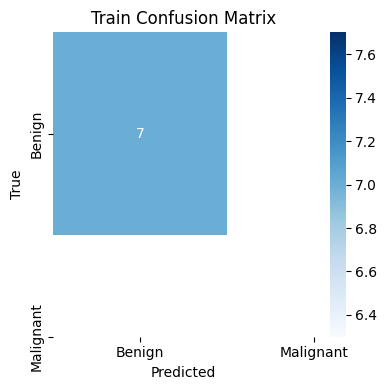

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 635ms/step

=== Validation Evaluation ===
AUC: nan | AP: 1.000 | Precision: 1.000 | Recall: 1.000 | F1: 1.000

Classification report:
              precision    recall  f1-score   support

           1      1.000     1.000     1.000         2

    accuracy                          1.000         2
   macro avg      1.000     1.000     1.000         2
weighted avg      1.000     1.000     1.000         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


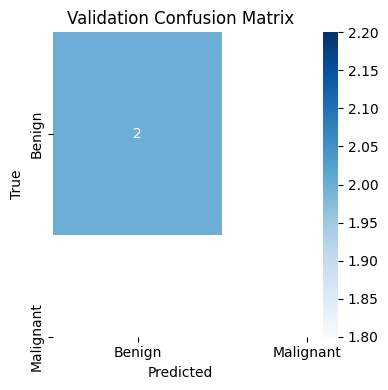

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

=== Test Evaluation ===
AUC: nan | AP: 1.000 | Precision: 1.000 | Recall: 1.000 | F1: 1.000

Classification report:
              precision    recall  f1-score   support

           1      1.000     1.000     1.000         2

    accuracy                          1.000         2
   macro avg      1.000     1.000     1.000         2
weighted avg      1.000     1.000     1.000         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


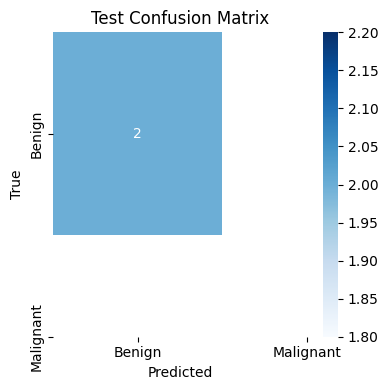

In [ ]:
# ============================================
# 11) EVALUATION REPORT (TRAIN / VAL / TEST)
# ============================================
def evaluate_split(model, X_img_, X_clin_, y_, X_rad_=None, split_name="Split"):
    inputs = [X_img_, X_clin_]
    if X_rad_ is not None:
        inputs.append(X_rad_)

    preds = model.predict(inputs, batch_size=BATCH_SIZE)
    probs = preds.ravel()
    labels = y_

    pred_bin = (probs >= 0.5).astype(int)
    auc = roc_auc_score(labels, probs)
    ap  = average_precision_score(labels, probs)
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, pred_bin, average="binary", zero_division=0
    )
    cm = confusion_matrix(labels, pred_bin)

    print(f"\n=== {split_name} Evaluation ===")
    print(f"AUC: {auc:.3f} | AP: {ap:.3f} | Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}")
    print("\nClassification report:")
    print(classification_report(labels, pred_bin, digits=3))

    plt.figure(figsize=(4,4))
    sns = __import__("seaborn")
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Benign", "Malignant"],
                yticklabels=["Benign", "Malignant"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{split_name} Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return {
        "auc": auc, "ap": ap, "precision": prec, "recall": rec, "f1": f1,
        "cm": cm, "labels": labels, "probs": probs
    }

train_metrics = evaluate_split(model, X_img_tr, X_clin_tr, y_tr, X_rad_tr, "Train")
val_metrics   = evaluate_split(model, X_img_va, X_clin_va, y_va, X_rad_va, "Validation")
test_metrics  = evaluate_split(model, X_img_te, X_clin_te, y_te, X_rad_te, "Test")


In [ ]:

# ============================================
# 12) SAVE FULL MODEL + LORA WEIGHTS
# ============================================
MODEL_DIR = PROJECT_ROOT / "models"
os.makedirs(MODEL_DIR, exist_ok=True)

full_model_path = MODEL_DIR / "multimodal_lora_full_model.h5"
model.save(full_model_path)
print("Saved full model to:", full_model_path)

fusion_layer = model.get_layer("fusion_lora_dense")

W = fusion_layer.base_dense.kernel.numpy()
b = fusion_layer.base_dense.bias.numpy() if fusion_layer.base_dense.bias is not None else None
A = fusion_layer.lora_A.numpy() if fusion_layer.lora_A is not None else None
B = fusion_layer.lora_B.numpy() if fusion_layer.lora_B is not None else None

lora_path = MODEL_DIR / "fusion_lora_weights_v1.npz"
np.savez(lora_path, W=W, A=A, B=B, b=b)
print("Saved fusion LoRA weights to:", lora_path)


Saved full model to: /content/drive/MyDrive/capstone/tumor_pred_ai/models/multimodal_lora_full_model.h5
Saved fusion LoRA weights to: /content/drive/MyDrive/capstone/tumor_pred_ai/models/fusion_lora_weights_v1.npz


Grad-CAM volume shape: (24, 24, 12)


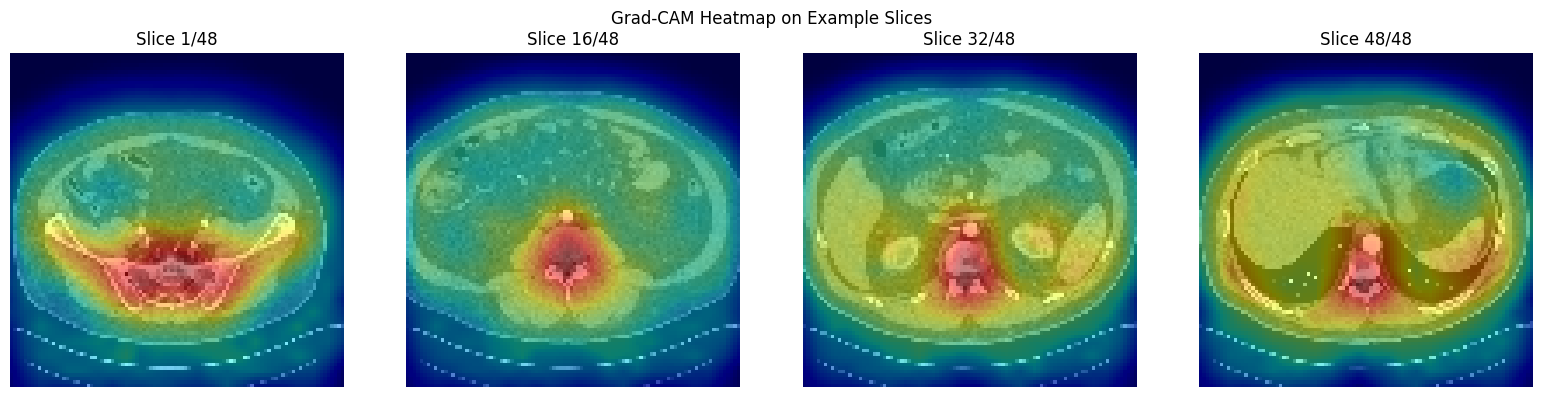

In [ ]:



# ============================================
# 13) OPTIONAL: SIMPLE GRAD-CAM FOR 3D IMAGE BRANCH
# ============================================
def grad_cam_3d(model, img_sample, clin_sample, rad_sample=None, target_layer_name="conv3d_2"):
    """
    img_sample: (1,H,W,D,1)
    clin_sample: (1, C_clin)
    """
    inputs = [img_sample, clin_sample]
    if rad_sample is not None:
        inputs.append(rad_sample)

    conv_layer = model.get_layer(target_layer_name)

    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(inputs, training=False)
        loss = predictions[:, 0]  # malignant score

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(1,2,3,4), keepdims=True)
    cam = tf.reduce_sum(pooled_grads * conv_outputs, axis=-1)  # (B,H,W,D)
    cam = tf.nn.relu(cam)
    cam = cam[0].numpy()
    cam = cam / (cam.max() + 1e-8)
    return cam  # (H,W,D)

# example on one validation sample (if exists)
if X_img_va.shape[0] > 0:
    img_sample = X_img_va[0:1]          # (1,H,W,D,1)
    clin_sample = X_clin_va[0:1]        # (1,C_clin)
    rad_sample = X_rad_va[0:1] if X_rad_va is not None else None

    cam_vol = grad_cam_3d(
        model,
        img_sample,
        clin_sample,
        rad_sample,
        target_layer_name="conv3d_2"
    )
    print("Grad-CAM volume shape:", cam_vol.shape)

    # original CT volume for the same sample
    vol_np = img_sample[0, :, :, :, 0]   # (H,W,D)
    H, W, D = vol_np.shape
    Hc, Wc, Dc = cam_vol.shape

    # --- resize CAM to match image volume shape ---
    # we already imported ndzoom earlier
    zoom_factors = (
        H / float(Hc if Hc > 0 else 1),
        W / float(Wc if Wc > 0 else 1),
        D / float(Dc if Dc > 0 else 1),
    )
    cam_resized = ndzoom(cam_vol, zoom_factors, order=1)  # (H,W,D)
    cam_resized = cam_resized / (cam_resized.max() + 1e-8)

    # pick 4 slices across the depth
    indices = np.linspace(0, D - 1, 4, dtype=int)

    plt.figure(figsize=(16, 4))
    for i, d in enumerate(indices):
        plt.subplot(1, 4, i + 1)
        plt.imshow(vol_np[:, :, d], cmap="gray")
        plt.imshow(cam_resized[:, :, d], cmap="jet", alpha=0.5)
        plt.axis("off")
        plt.title(f"Slice {d+1}/{D}")
    plt.suptitle("Grad-CAM Heatmap on Example Slices")
    plt.tight_layout()
    plt.show()




[info] Initialising SHAP KernelExplainer (this is slow)...
[info] Computing SHAP values on small validation subset...


  0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 2 iterations, i.e. alpha=1.370e-03, with an active set of 2 regressors, and the smallest cholesky pivot element being 2.980e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(


SHAP values shape after processing: (2, 27)


/tmp/ipython-input-437941168.py:52: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


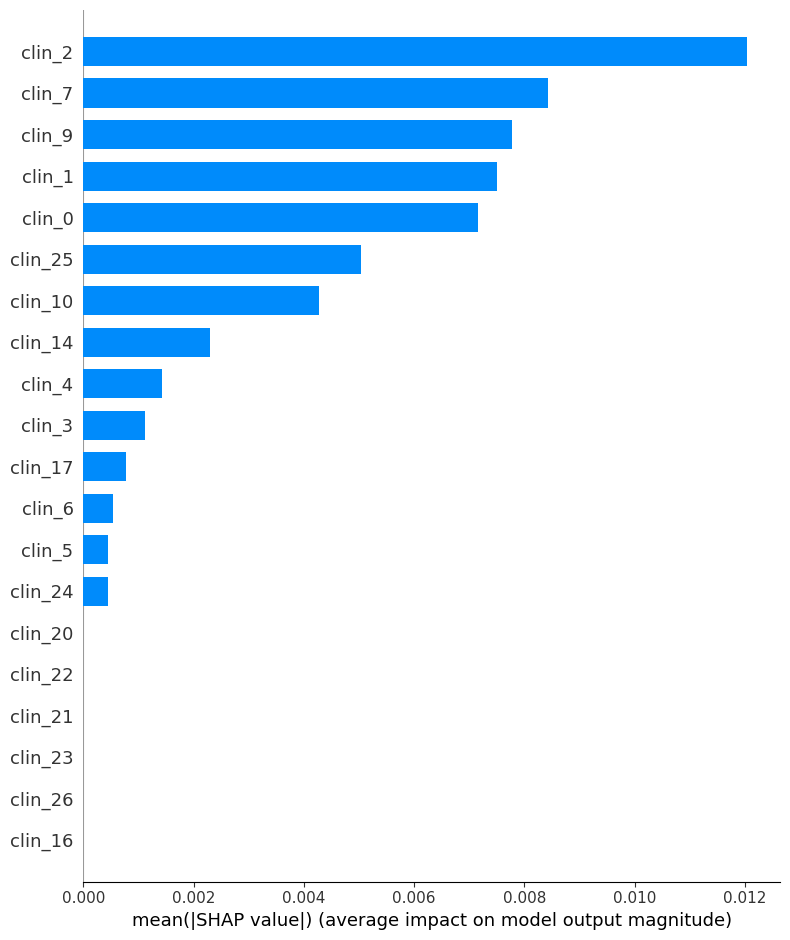

In [ ]:
# ============================================
# 14) OPTIONAL: SHAP FOR CLINICAL FEATURES ONLY
# ============================================

RUN_SHAP = True  # <-- set to True ONLY when you really need SHAP plots

if RUN_SHAP and X_clin_tr.shape[0] > 0:
    # much smaller subsets to keep runtime reasonable
    subset_size = min(20, X_clin_tr.shape[0])
    background_clin = X_clin_tr[:subset_size]
    test_clin = X_clin_va[:10] if X_clin_va.shape[0] >= 10 else X_clin_va

    # dummy zero image and optional radiomics, kept fixed
    dummy_img = np.zeros_like(X_img_tr[:1])
    dummy_rad = np.zeros_like(X_rad_tr[:1]) if X_rad_tr is not None else None

    def clinical_only_model(clin_batch):
        # clin_batch: (B, C_clin)
        B = clin_batch.shape[0]
        img_batch = np.repeat(dummy_img, B, axis=0)
        inputs = [img_batch, clin_batch]
        if dummy_rad is not None:
            rad_batch = np.repeat(dummy_rad, B, axis=0)
            inputs.append(rad_batch)
        preds = model.predict(inputs, verbose=0)
        return preds

    print("[info] Initialising SHAP KernelExplainer (this is slow)...")
    explainer = shap.KernelExplainer(clinical_only_model, background_clin)

    print("[info] Computing SHAP values on small validation subset...")

    # Get the raw SHAP values from the explainer
    raw_shap_values = explainer.shap_values(test_clin, nsamples=30)

    # For a single-output Keras model, shap.KernelExplainer often returns
    # an array of shape (num_samples, num_features, 1). We need to handle this.
    if isinstance(raw_shap_values, list):
        # This branch handles cases where SHAP might return a list of arrays (e.g., for multi-class)
        # We select the SHAP values for the first class (index 0)
        shap_values = raw_shap_values[0]
    else:
        # This is for single-output models, where raw_shap_values is directly a NumPy array
        shap_values = raw_shap_values

    # Squeeze any trailing singleton dimensions, particularly (num_samples, num_features, 1) -> (num_samples, num_features)
    if shap_values.ndim == 3 and shap_values.shape[-1] == 1:
        shap_values = np.squeeze(shap_values, axis=-1)

    print("SHAP values shape after processing:", shap_values.shape)

    shap.summary_plot(
        shap_values,
        test_clin,
        feature_names=[f"clin_{i}" for i in range(X_clin_tr.shape[1])],
        plot_type="bar"
    )
else:
    print("[info] Skipping SHAP computation (RUN_SHAP = False).")

In [ ]:
# ===== Cell: Drift detection and LoRA retraining =====
# IMPORTANT: This section is written for PyTorch models.
# The main model in this notebook uses TensorFlow/Keras.
# You will need to adapt this code for TensorFlow or ensure PyTorch is fully integrated.
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from scipy.spatial.distance import euclidean

# reference stats from training data
ref_mean = X_clin_tr.mean(axis=0)
ref_std  = X_clin_tr.std(axis=0) + 1e-6

def compute_feature_shift(new_clin):
    new_mean = new_clin.mean(axis=0)
    new_std  = new_clin.std(axis=0) + 1e-6
    mean_shift = euclidean(ref_mean, new_mean) / len(ref_mean)
    std_shift  = euclidean(ref_std, new_std) / len(ref_std)
    return mean_shift, std_shift

DRIFT_THRESHOLD_MEAN = 0.1   # tune these thresholds
DRIFT_THRESHOLD_STD  = 0.1

def check_drift(new_clin):
    m_shift, s_shift = compute_feature_shift(new_clin)
    print(f"Mean shift: {m_shift:.4f}, Std shift: {s_shift:.4f}")
    return (m_shift > DRIFT_THRESHOLD_MEAN) or (s_shift > DRIFT_THRESHOLD_STD)

def lora_parameters(model):
    yield model.fusion_head.lora_A
    yield model.fusion_head.lora_B

def finetune_lora_on_new_data(model, new_loader, epochs=3, lr=5e-5):
    model.train()
    # freeze everything except LoRA matrices
    for p in model.parameters():
        p.requires_grad = False
    for p in lora_parameters(model):
        p.requires_grad = True

    opt = torch.optim.Adam(lora_parameters(model), lr=lr)
    crit = nn.CrossEntropyLoss()

    for ep in range(1, epochs+1):
        running_loss = 0.0
        all_labels, all_probs = [], []
        for imgs, clin, labels in new_loader:
            imgs = imgs.to(DEVICE)
            clin = clin.to(DEVICE)
            labels = labels.to(DEVICE)

            opt.zero_grad()
            logits = model(imgs, clin)
            loss = crit(logits, labels)
            loss.backward()
            opt.step()

            running_loss += loss.item() * labels.size(0)
            probs = torch.softmax(logits, dim=1)[:,1]
            all_labels.extend(labels.cpu().numpy().tolist())
            all_probs.extend(probs.detach().cpu().numpy().tolist())

        all_labels = np.array(all_labels)
        all_probs = np.array(all_probs)
        preds = (all_probs >= 0.5).astype(int)
        auc = roc_auc_score(all_labels, all_probs)
        print(f"[LoRA fine-tune] Epoch {ep} | Loss {running_loss/len(all_labels):.4f} | AUC {auc:.3f}")

    # save new LoRA state
    new_lora_state = {
        "fusion_head.lora_A": model.fusion_head.lora_A.detach().cpu(),
        "fusion_head.lora_B": model.fusion_head.lora_B.detach().cpu(),
    }
    version_id = np.random.randint(100000)
    out_path = os.path.join(MODEL_DIR, f"lora_only_v{version_id}.pt")
    torch.save(new_lora_state, out_path)
    print("Saved updated LoRA weights to", out_path)
    return out_path


In [ ]:
# ============================================
# 15) OPTIONAL (PSEUDO): DRIFT CHECK + LoRA FINE-TUNE (PYTORCH)
# ============================================
# NOTE:
# The main notebook uses TensorFlow/Keras for `model`.
# This PyTorch snippet is provided as a conceptual template only.
# Do NOT run this cell unless you replace `model` with a PyTorch model
# and implement a proper MultimodalDataset in PyTorch.

"""
from torch.utils.data import Dataset, DataLoader

class MultimodalDataset(Dataset):
    def __init__(self, X_img, X_clin, y):
        self.X_img = X_img
        self.X_clin = X_clin
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        img = torch.tensor(self.X_img[idx], dtype=torch.float32)
        clin = torch.tensor(self.X_clin[idx], dtype=torch.float32)
        label = torch.tensor(self.y[idx], dtype=torch.long)
        return img, clin, label

# Example: new incoming batch (already preprocessed like training data)
# X_img_new: (N_new, D, H, W, C)
# X_clin_new: (N_new, C_clin)
# y_new: (N_new,)
new_ds = MultimodalDataset(X_img_new, X_clin_new, y_new)
new_loader = DataLoader(new_ds, batch_size=BATCH_SIZE, shuffle=True)

if check_drift(X_clin_new):
    print("Drift detected. Fine-tuning LoRA layers...")
    lora_path_new = finetune_lora_on_new_data(model, new_loader)
else:
    print("No significant drift detected.") TODO add daatset class in train/valset
"""


'\nfrom torch.utils.data import Dataset, DataLoader\n\nclass MultimodalDataset(Dataset):\n    def __init__(self, X_img, X_clin, y):\n        self.X_img = X_img\n        self.X_clin = X_clin\n        self.y = y\n\n    def __len__(self):\n        return len(self.y)\n\n    def __getitem__(self, idx):\n        img = torch.tensor(self.X_img[idx], dtype=torch.float32)\n        clin = torch.tensor(self.X_clin[idx], dtype=torch.float32)\n        label = torch.tensor(self.y[idx], dtype=torch.long)\n        return img, clin, label\n\n# Example: new incoming batch (already preprocessed like training data)\n# X_img_new: (N_new, D, H, W, C)\n# X_clin_new: (N_new, C_clin)\n# y_new: (N_new,)\nnew_ds = MultimodalDataset(X_img_new, X_clin_new, y_new)\nnew_loader = DataLoader(new_ds, batch_size=BATCH_SIZE, shuffle=True)\n\nif check_drift(X_clin_new):\n    print("Drift detected. Fine-tuning LoRA layers...")\n    lora_path_new = finetune_lora_on_new_data(model, new_loader)\nelse:\n    print("No significan

In [ ]:

# 16) SINGLE-PATIENT INFERENCE HELPER
# ============================================
from tensorflow.keras.models import load_model
full_model_path="/content/drive/MyDrive/capstone/tumor_pred_ai/models/multimodal_lora_full_model.h5"

# Reload model (e.g., in a fresh session)
custom_objects = {"LoRADense": LoRADense}
inference_model = load_model(full_model_path, custom_objects=custom_objects)
print("Loaded model for inference from:", full_model_path)

def predict_patient(
    model,
    img_vol,
    clin_features,
    rad_features=None,
    threshold=0.5,
):
    """
    img_vol:      3D CT volume already preprocessed to same shape as X_img (D,H,W,1)
    clin_features:1D array of scaled clinical features (same order as X_clin_scaled columns)
    rad_features: 1D array of scaled radiomics features (or None if not used)
    """

    img = np.asarray(img_vol, dtype="float32")
    clin = np.asarray(clin_features, dtype="float32")

    # add batch dimension
    img  = np.expand_dims(img, axis=0)   # (1, D, H, W, 1)
    clin = np.expand_dims(clin, axis=0)  # (1, C_clin)

    inputs = [img, clin]

    if rad_features is not None:
        rad = np.asarray(rad_features, dtype="float32")
        rad = np.expand_dims(rad, axis=0)  # (1, C_rad)
        inputs.append(rad)

    prob = model.predict(inputs, batch_size=1).ravel()[0]
    label = int(prob >= threshold)

    return prob, label

# Example: run inference on one test patient
example_idx = 0
example_img  = X_img_te[example_idx]
example_clin = X_clin_te[example_idx]
example_rad  = X_rad_te[example_idx] if X_rad_te is not None else None

prob, label = predict_patient(inference_model, example_img, example_clin, example_rad)
print(f"Malignancy probability: {prob:.3f}  -> Predicted label: {label}")


Loaded model for inference from: /content/drive/MyDrive/capstone/tumor_pred_ai/models/multimodal_lora_full_model.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 607ms/step
Malignancy probability: 0.546  -> Predicted label: 1


In [ ]:
# streamlit_app.py
import numpy as np
import streamlit as st
from pathlib import Path
from tensorflow.keras.models import load_model

# Import your custom LoRA layer from the same module / copy class definition



# ----- CONFIG -----
PROJECT_ROOT = Path("/content/drive/MyDrive/capstone/tumor_pred_ai")  # adjust if needed
MODEL_DIR = PROJECT_ROOT / "models"
FULL_MODEL_PATH = MODEL_DIR / "multimodal_lora_full_model.h5"

# If you saved scalers, load them here:
# import joblib
# clin_scaler = joblib.load(MODEL_DIR / "clin_scaler.pkl")
# rad_scaler  = joblib.load(MODEL_DIR / "rad_scaler.pkl")

@st.cache_resource
def load_inference_model():
    custom_objects = {"LoRADense": LoRADense}
    model = load_model(FULL_MODEL_PATH, custom_objects=custom_objects)
    return model

def predict_patient(model, img_vol, clin_features, rad_features=None, threshold=0.5):
    img = np.asarray(img_vol, dtype="float32")
    clin = np.asarray(clin_features, dtype="float32")

    img  = np.expand_dims(img, axis=0)   # (1, D, H, W, 1)
    clin = np.expand_dims(clin, axis=0)  # (1, C_clin)

    inputs = [img, clin]

    if rad_features is not None:
        rad = np.asarray(rad_features, dtype="float32")
        rad = np.expand_dims(rad, axis=0)
        inputs.append(rad)

    prob = model.predict(inputs, batch_size=1).ravel()[0]
    label = int(prob >= threshold)
    return prob, label

# ============ STREAMLIT UI ============
st.title("Kidney Tumor Multimodal Predictor ")
st.write("CT volume + clinical features (and optional radiomics) → malignancy probability.")

model = load_inference_model()

st.sidebar.header("Clinical Features")
# Example clinical inputs – replace with your real feature names/ranges
age = st.sidebar.number_input("Age at nephrectomy", min_value=0, max_value=120, value=60)
bmi = st.sidebar.number_input("Body Mass Index", min_value=10.0, max_value=60.0, value=25.0)
rad_size = st.sidebar.number_input("Radiographic size (cm)", min_value=0.0, max_value=30.0, value=5.0)

# Build clinical feature vector in the same order as X_clin_scaled columns
# Here is just an example; adapt to your actual order!
clin_vec_raw = np.array([age, bmi, rad_size], dtype="float32")

# If you used a scaler during training, apply it:
# clin_vec = clin_scaler.transform(clin_vec_raw.reshape(1, -1)).ravel()
clin_vec = clin_vec_raw  # if already scaled or using raw in demo

st.header("CT Volume Input")
st.write("For now, upload a preprocessed NumPy `.npy` volume with shape `(D, H, W, 1)`.")

uploaded_file = st.file_uploader("Upload CT volume (.npy)", type=["npy"])

rad_vec = None
# If you want radiomics input via UI you can add numeric fields here
# or load from a file:
# rad_uploaded = st.file_uploader("Upload radiomics features (.npy)", type=["npy"])
# if rad_uploaded is not None:
#     rad_vec = np.load(rad_uploaded)

if uploaded_file is not None:
    img_vol = np.load(uploaded_file)
    st.write(f"Loaded volume shape: {img_vol.shape}")

    if st.button("Run Prediction"):
        prob, label = predict_patient(model, img_vol, clin_vec, rad_vec)
        st.subheader("Results")
        st.write(f"**Malignancy probability:** {prob:.3f}")
        st.write(f"**Predicted label:** {'Malignant' if label == 1 else 'Benign'}")
else:
    st.info("Upload a `.npy` CT volume to enable prediction.")


2025-11-18 23:59:41.817 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-18 23:59:41.818 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-18 23:59:41.819 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-18 23:59:41.819 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-18 23:59:41.820 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-18 23:59:41.820 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-18 23:59:41.821 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-18 23:59:41.821 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar